In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [10]:
df=pd.read_csv(r"C:\Users\aditi\Downloads\archive (6)\creditcard.csv")
print(df)

            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  0.098698  0.363787  ... -0.01830

In [12]:
print("the shape of the dataset")
print(df.shape)
print("the datatypes of datset")
print(df.dtypes)
print("it check any null value is there or not")
print(df.isnull())
print("is there any duplicated value")
print(df.duplicated().sum())

the shape of the dataset
(284807, 31)
the datatypes of datset
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
it check any null value is there or not
         Time     V1     V2     V3     V4     V5     V6     V7     V8     V9  \
0       False  False  False  False  False  False  False  False  False  False   
1       False  False  False  False  False  False  False  False  False  False   
2       False  False  False  False  False  False  False  False  False  False   
3     

In [13]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)
corr = df.corr()['Class'].sort_values(ascending=False)
print(corr)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(columns=['Amount', 'Time'])
print(df[['Amount_scaled', 'Time_scaled']].describe())

       Amount_scaled   Time_scaled
count   2.848070e+05  2.848070e+05
mean    2.913952e-17 -3.065637e-16
std     1.000002e+00  1.000002e+00
min    -3.532294e-01 -1.996583e+00
25%    -3.308401e-01 -8.552120e-01
50%    -2.652715e-01 -2.131453e-01
75%    -4.471707e-02  9.372174e-01
max     1.023622e+02  1.642058e+00


In [18]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Class'])
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True) * 100)

(227845, 30) (56962, 30)
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

[[55475  1389]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9721669425367221


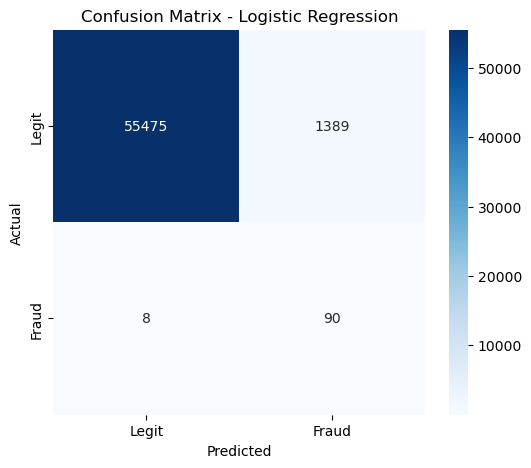

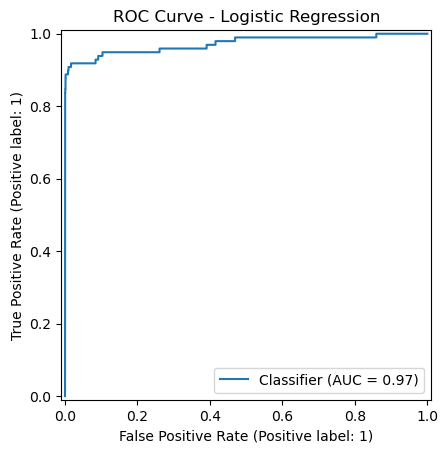

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()
# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve - Logistic Regression')
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

[[56861     3]
 [   24    74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9580757668852571


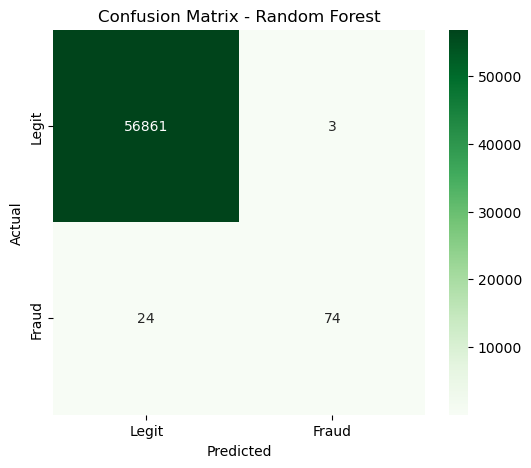

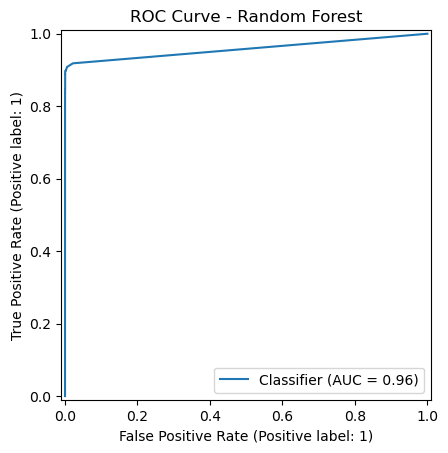

In [26]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title('ROC Curve - Random Forest')
plt.show()

V14    0.209957
V10    0.117426
V4     0.114338
V17    0.087294
V12    0.072589
V11    0.071794
V3     0.068853
V16    0.037364
V7     0.031199
V2     0.025360
dtype: float64


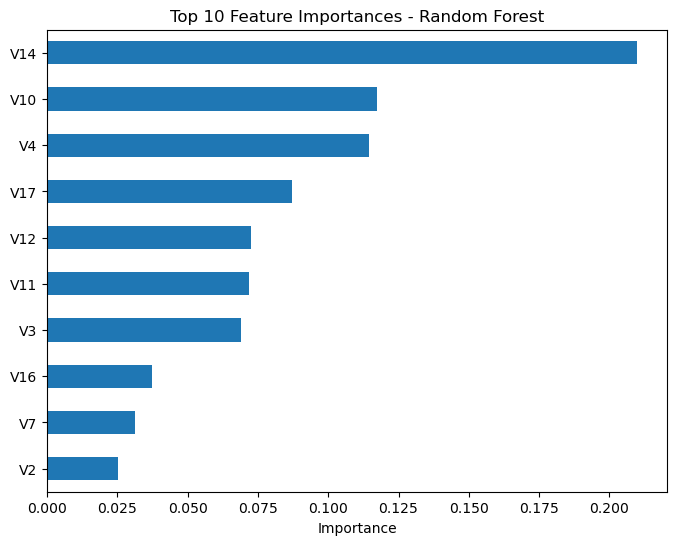

In [28]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))
plt.figure(figsize=(8,6))
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.show()

In [30]:
# Cost-benefit framing
cost_missed_fraud = 5000   # assumed avg cost of a missed fraud case (₹)
cost_false_alarm = 50      # assumed cost of a false alarm (customer friction, manual review)
# Logistic Regression
fn_lr, fp_lr = 8, 1389
cost_lr = (fn_lr * cost_missed_fraud) + (fp_lr * cost_false_alarm)
# Random Forest
fn_rf, fp_rf = 24, 3
cost_rf = (fn_rf * cost_missed_fraud) + (fp_rf * cost_false_alarm)
print(f"Logistic Regression estimated cost: ₹{cost_lr:,}")
print(f"Random Forest estimated cost: ₹{cost_rf:,}")

Logistic Regression estimated cost: ₹109,450
Random Forest estimated cost: ₹120,150


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Rebuild from original unscaled data for a clean pipeline
X_raw = df.drop(columns=['Class'])  # if Amount/Time already scaled+dropped, reload df fresh instead
y = df['Class']

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
pipeline.fit(X_train, y_train)
print("Pipeline ROC-AUC:", roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1]))

Pipeline ROC-AUC: 0.9720834996210077


In [34]:
def predict_transaction(transaction_values, model, threshold=0.5):
    """
    transaction_values: dict or list matching X_train's column order
    model: trained pipeline or model
    threshold: probability cutoff for flagging as fraud
    """
    input_df = pd.DataFrame([transaction_values], columns=X_train.columns)
    proba = model.predict_proba(input_df)[0][1]
    prediction = "FRAUD" if proba >= threshold else "LEGIT"
    return {
        "fraud_probability": round(proba, 4),
        "prediction": prediction
    }
# Example: grab one real test row and check it
sample = X_test.iloc[0].to_dict()
result = predict_transaction(sample, pipeline)
print(result)
print("Actual label:", y_test.iloc[0])

{'fraud_probability': 0.0057, 'prediction': 'LEGIT'}
Actual label: 0


In [36]:
# Find a fraud case in the test set
fraud_indices = y_test[y_test == 1].index
sample_fraud = X_test.loc[fraud_indices[0]].to_dict()
result_fraud = predict_transaction(sample_fraud, pipeline)
print(result_fraud)
print("Actual label:", y_test.loc[fraud_indices[0]])

{'fraud_probability': 1.0, 'prediction': 'FRAUD'}
Actual label: 1


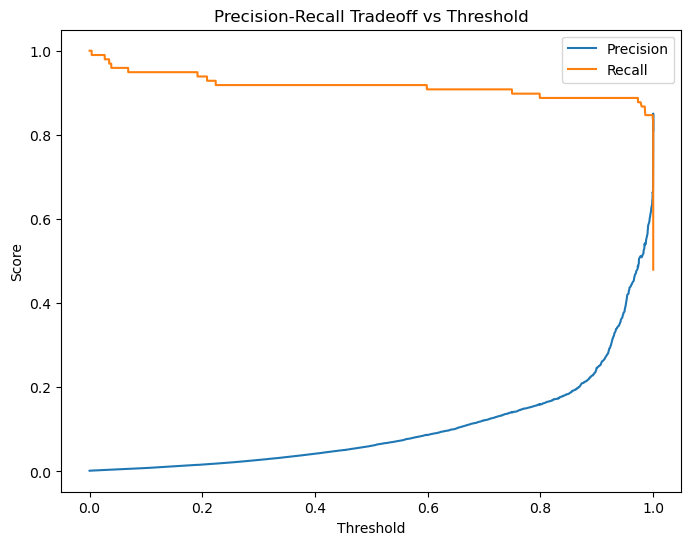

In [38]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, pipeline.predict_proba(X_test)[:,1])
plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff vs Threshold')
plt.legend()
plt.show()

In [40]:
for t in [0.3, 0.5, 0.7, 0.85, 0.9, 0.95]:
    preds = (pipeline.predict_proba(X_test)[:,1] >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"Threshold {t}: Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")

Threshold 0.3: Precision=0.027, Recall=0.918, F1=0.053
Threshold 0.5: Precision=0.061, Recall=0.918, F1=0.114
Threshold 0.7: Precision=0.121, Recall=0.908, F1=0.214
Threshold 0.85: Precision=0.185, Recall=0.888, F1=0.306
Threshold 0.9: Precision=0.247, Recall=0.888, F1=0.387
Threshold 0.95: Precision=0.390, Recall=0.888, F1=0.542


In [42]:
import joblib
joblib.dump(pipeline, 'fraud_detection_model.joblib')
print("Model saved.")
# Quick reload test
loaded_model = joblib.load('fraud_detection_model.joblib')
print("Reload check ROC-AUC:", roc_auc_score(y_test, loaded_model.predict_proba(X_test)[:,1]))

Model saved.
Reload check ROC-AUC: 0.9720834996210077


In [44]:
# Export the test set with predictions for dashboard use
export_df = X_test.copy()
export_df['actual_class'] = y_test.values
export_df['predicted_proba'] = pipeline.predict_proba(X_test)[:,1]
export_df['predicted_class'] = (export_df['predicted_proba'] >= 0.95).astype(int)
export_df.to_csv('fraud_predictions_for_tableau.csv', index=False)
print(export_df.shape)
print(export_df.head())

(56962, 33)
              V1        V2        V3        V4        V5        V6        V7  \
263020 -0.674466  1.408105 -1.110622 -1.328366  1.388996 -1.308439  1.885879   
11378  -2.829816 -2.765149  2.537793 -1.074580  2.842559 -2.153536 -1.795519   
147283 -3.576495  2.318422  1.306985  3.263665  1.127818  2.865246  1.444125   
219439  2.060386 -0.015382 -1.082544  0.386019 -0.024331 -1.074935  0.207792   
36939   1.209965  1.384303 -1.343531  1.763636  0.662351 -2.113384  0.854039   

              V8        V9       V10  ...       V24       V25       V26  \
263020 -0.614233  0.311652  0.650757  ...  0.707899 -0.135837  0.045102   
11378  -0.250020  3.073504 -1.000418  ...  0.042996 -0.027660 -0.910247   
147283 -0.718922  1.874046  7.398491  ... -1.483996 -0.296011  0.062823   
219439 -0.338140  0.455091  0.047859  ... -0.067584 -0.283675  0.203529   
36939  -0.475963 -0.629658 -1.579654  ...  0.619449  0.818998 -0.330525   

             V27       V28  Amount_scaled  Time_scaled  

In [46]:
import os
print(os.getcwd())

C:\Users\aditi
